# Computer Vision (Partie 1) - 23/03/2026

Dans ce notebook, nous verrons comment les bases de l'analyse par computer vision. En nous focalisant sur la détection de couleurs.

Comme toujours, toutes les cellules peuvent être executées dans l'ordre, mais essayez de prédire la sortie de chaque cellule avant de l'exécuter.
N'hésitez pas à jouer avec le code, le bidouiller pour tester des alternatives — c'est l'un des grands avantages d'utiliser un notebook.

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cv2

## Partie 1 - Préparation

Nous allons travailler pour ce notebook sur un corpus de tableaux et détails de Piero della Francesca.

Il s'agira dans un premier temps de préparer les données, puis de faire des analyses simples sur le contenu colorimétrique, avant de jouer avec la segmentation de l'image.

In [21]:
df.loc[df['title'].str.contains('detail')]

,ID,artist,title,picture data,file info,jpg url
0,31313,PIERO DELLA FRANCESCA,8. battle between heraclius and chosroes (detail),"1452-66, fresco, san francesco, arezzo","1000*1181, true color, 207 kb",https://www.wga.hu/art/p/piero/2/8/8herac18.jpg
1,31314,PIERO DELLA FRANCESCA,8. battle between heraclius and chosroes (detail),"1452-66, fresco, san francesco, arezzo","850*968, true color, 179 kb",https://www.wga.hu/art/p/piero/2/8/8herac19.jpg
3,31316,PIERO DELLA FRANCESCA,9. exaltation of the cross (detail),"1452-66, fresco, san francesco, arezzo","1000*1170, true color, 214 kb",https://www.wga.hu/art/p/piero/2/9/9exal02.jpg
4,31317,PIERO DELLA FRANCESCA,9. exaltation of the cross (detail),"1452-66, fresco, san francesco, arezzo","900*1053, true color, 203 kb",https://www.wga.hu/art/p/piero/2/9/9exal03.jpg
5,31318,PIERO DELLA FRANCESCA,9. exaltation of the cross (detail),"1452-66, fresco, san francesco, arezzo","800*933, true color, 205 kb",https://www.wga.hu/art/p/piero/2/9/9exal04.jpg
...,...,...,...,...,...,...
185,31498,PIERO DELLA FRANCESCA,4. vision of constantine (detail),"1452-66, fresco, san francesco, arezzo","900*1051, true color, 168 kb",https://www.wga.hu/art/p/piero/2/4/4vision4.jpg
186,31499,PIERO DELLA FRANCESCA,4. vision of constantine (detail),"1452-66, fresco, san francesco, arezzo","900*1040, true color, 181 kb",https://www.wga.hu/art/p/piero/2/4/4vision5.jpg
187,31500,PIERO DELLA FRANCESCA,4. vision of constantine (detail),"1452-66, fresco, san francesco, arezzo","1000*1091, true color, 186 kb",https://www.wga.hu/art/p/piero/2/4/4vision6.jpg
188,31501,PIERO DELLA FRANCESCA,3. burial of the holy wood (detail),"1452-66, fresco, san francesco, arezzo","800*938, true color, 159 kb",https://www.wga.hu/art/p/piero/2/3/3burial3.jpg


### Exercice 1 - Préparation des données

Commençons par préparer les données qui nous intéressent, et qui seront utiles à l'analyse.


❓ À partir des métadonnées existantes, créez dans la DataFrame les colonnes suivantes:
- "detail", qui est `True` quand l'image est un détail et `False` autrement
- "original_title", qui est le titre de l'oeuvre complète quand l'image est un détail
- "date"
- "location", le lieu de conservation (nom du musée, église, etc.)
- "city", la ville de conservation
- "technique"
- "object_dimensions", quand celles-ci sont connues

❓ Ensuite, ordonnez la dataframe par nom d'oeuvre originale

In [142]:
# Votre réponse ici

❓ Essayez maintenant d'extraire une date (la première) pour chacun des tableaux

In [55]:
# Votre code ici.

❓ Ajoutez une colonne qui donne le chemin vers l'image correspondante

In [56]:
# Votre code ici

#### Réponses Exercice 1 (à masquer)


In [ ]:

df = pd.read_csv("./data/piero/piero_dataset.csv")

df['detail'] = df['title'].str.contains('detail')
df['original_title'] = df['title'].str.replace(' (detail)', '')
df['date'] = df['picture data'].apply(lambda x: x.split(',')[0])
df['location'] = df['picture data'].apply(lambda x: x.split(',')[-2])
df['city'] = df['picture data'].apply(lambda x: x.split(',')[-1])
df['technique'] = df['picture data'].apply(lambda x: x.split(',')[1])
df['object_dimensions'] = df['picture data'].apply(lambda x: x.split(',')[2] if len(x.split(','))==5 else None)
df = df.sort_values(['original_title', 'detail'])


df['year'] = df['date'].apply(lambda x: int(x.replace('c. ', '').split('-')[0]) if x!='-' else None)



df['path'] = df['ID'].apply(lambda x: f"./data/piero/{x}.jpg")

## Partie 2 - Colorimétrie

Commençons par des compétences de base dans l'analyse des images numériques : 
- les dimensions des images
- repérer les couleurs


Commençons avec un exercice plus facile, qui nous permettra de récupérer la dimension de l'image, et surtout de mettre en place une boucle sur les images que nous pourrons réutiliser plus tard.


❓ En ouvrant chaque image, ajoutez une colonne donnant les dimensions de l'image.


Petit rappel, pour itérer sur une `DataFrame`, vous pouvez utiliser la méthode `<dataframe>.iterrows()` qui vous renvoie l'index de la ligne et son contenu:

Par exemple, 
```
for idx, row in df.iterrows():
    <quelque chose>
```


Ici, essayez donc d'ouvrir chaque image dans la boucle avec cv2, et récupérez ses dimensinons. Stockez les ensuite dans un dictionnaire ou une liste (au choix) pour créer une nouvelle colonner

In [63]:
# Votre réponse ici

### 1.1. Détection de couleurs

Une question souvent traitée avec les images numériques est celle de la couleur : détecter les couleurs dominantes, identifier les régions qui contiennent telle ou telle couleur, etc.

Pour travailler avec la couleur, rappelons-nous que celle-ci est constituée de trois dimensions (souvent Rouge, Vert, Bleu). C'est donc un point dans un espace tri-dimensionnel.

❓ Que signifie donc une proximité colorimétrique, si l'on considère la couleur comme un point dans l'espace ?

*Votre réponse ici*

Jouons donc désormais avec une image, et ses informations colorimétriques.

Par exemple, ouvrons l'image `31314.jpg` et cartographions la présence de la couleur rouge

❗ N'oubliez pas que `cv2` ouvre les images en mode BGR et non RGB. Rappelez-vous donc bien de convertir l'image comme nous l'avons vu dans le cours 2.

In [146]:
image = cv2.imread('./data/cours_23-03/piero/31314.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Pour choisir une "colormap", il faut spécifier le paramètre `cmap`. 

Et pour l'afficher, bien appeler la fonction de matplotlib `plt.colorbar()`:

Text(0.5, 1.0, 'Degré de présence du rouge')

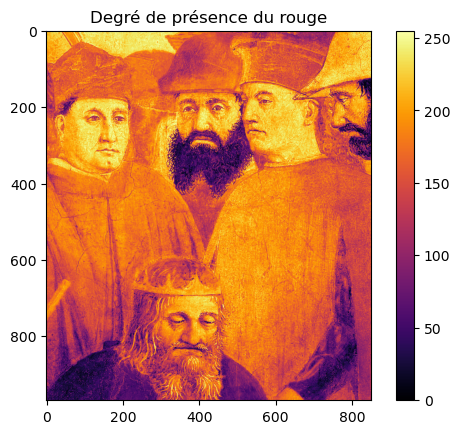

In [147]:
plt.imshow(image[:,:,0], vmin=0, vmax=255, cmap='inferno')
plt.colorbar()
plt.title('Degré de présence du rouge')

❓ Faites maintenant la même chose avec le vert.

In [78]:
# Votre réponse ici.

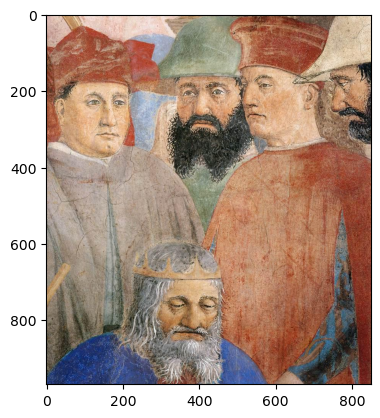

In [148]:
plt.imshow(image)

Pour détecter la couleur moyenne d'une image, nous pouvons utiliser la fonction `cv2.mean()`.

❓ Que font les lignes suivantes ? Pourquoi avons-nous besoin du `[:3]` de la première ligne ?

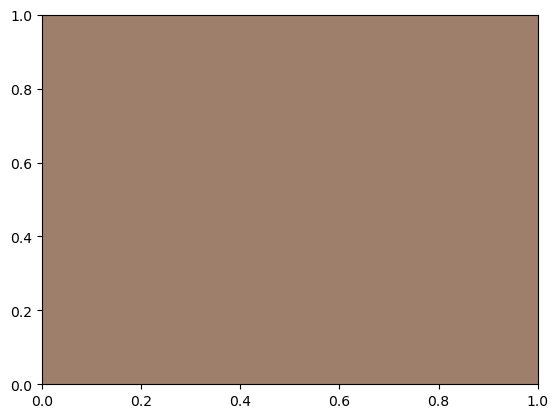

In [149]:
average_colour = (np.array(cv2.mean(image))/255)[:3]


ax = plt.subplot()
rect = plt.Rectangle((0,0),10,10,color=average_colour)
ax.add_patch(rect)

❓ Quelles sont les couleurs moyennes des images 31322 et 31324 ?

In [96]:
# Votre réponse ici

### 1.2. Profil colorimétrique

Voyons ici comment faire pour représenter le profil des couleurs d'une image en 3D:

In [ ]:

def plot_rgb_3d(pixels, sample_size=5000):


    # Prenons un subset (plus rapide)
    if len(pixels) > sample_size:
        idx = np.random.choice(len(pixels), sample_size, replace=False)
        pixels = pixels[idx]

    # Normaliser pour convertir les pixels en valeurs entre 0 et 1
    colors = pixels / 255.0

    r = pixels[:, 0]
    g = pixels[:, 1]
    b = pixels[:, 2]


    # Représentation 3D (avec l'argument projection='3d')
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.scatter(r, g, b, c=colors, s=5)

    ax.set_xlabel('Rouge')
    ax.set_ylabel('Vert')
    ax.set_zlabel('Bleu')

    ax.set_xlim([0, 255])
    ax.set_ylim([0, 255])
    ax.set_zlim([0, 255])

    plt.show()

# Applatit la matrice en une liste de pixels
pixels = image.reshape(-1, 3)

plot_rgb_3d(pixels)

#### Exercice 2 - Profil colorimétrique

- Modifiez le code ci-dessus pour pouvoir prendre en entrée un chemin vers une image
- Affichez le tableau original à côté du profil colorimétrique (via `plt.subplots()')

### 1.3. Filtrer une image avec une condition


Une image numérique n'étant qu'une matrice de nombres, il est possible de la filtrer sur la base de conditions numériques (par exemple, la proximité à une couleur précise).

Supposons par exemple, que nous voulons tester la présence d'une teinte de bleu (RBG: (173, 189, 219)). Les étapes seraient les suivantes :

- Calculer la distance entre la couleur de chaque pixel et la couleur cible
- Déterminer si cette distance est au-dessus ou en-dessous d'un seuil arbitraire. (Ce qui renvoie une matrice booléenne, faite de Vrai/Faux)
- Afficher cette matrice booléenne / calculer sa surface, etc.

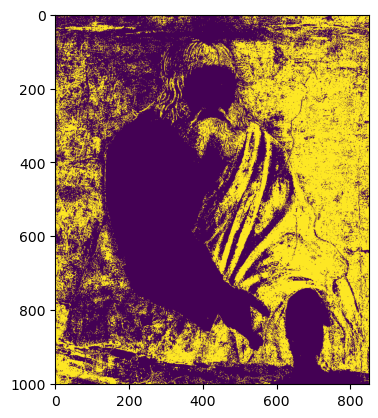

In [136]:
# Commençons par définir la couleur cible, et le seuil
# Notez bien que l'on exprime la couleur en matrice (et pas juste en tuple)
target_colour = np.array((173, 189, 219))
threshold = 50

# Ensuite, nous convertissons l'image en float (en nombre rationnel)
img = image.astype(np.float32)

# Pour chaque point, on calcule la distance euclidienne entre la couleur du pixel et la couleur cible
dist = np.linalg.norm(img - target_colour, axis=2)

# ❓ Pourquoi doit-on spécificer axis=2?

# À partir de cette distance, on calcule un masque booléen
mask_bool = dist < threshold

# Enfin, nous pouvons le représenter
plt.imshow(mask_bool)


Pour affiner un peu ce que nous avons fait, il est possible de combiner le masque pour extraire des régions de l'image originale, via la fonction `cv2.bitwise_and()`.
❗ Cette fonction prend comme entrée un masque non pas booléen (True/False) mais entier (où True=1, False=0)

❓ Que renvoie la fonction `cv2.bitwise_and()` ?

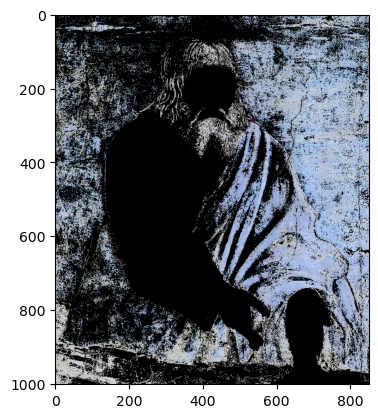

In [138]:
# Convertir le masque booléen en masque entier
mask_int = (mask_bool.astype(np.uint8))

# Appliquer le masque à l'image originale
result = cv2.bitwise_and(image, image, mask=mask_int)

plt.imshow(result)

❓ Quel est la part de l'image qui contient la couleur cible ? Utilisez le résultat des opérations précédentes (en part. le masque).

In [140]:
# Votre réponse ici

#### Exercice 2

Pour toutes les images de notre corpus, calculez la surface couverte par une couleur de votre choix. Par exemple, `(173, 189, 219)` (bleu) ou bien `(141,83,60)` (rouge).

Jouez aussi sur la valeur que vous choississez pour le seuil de détection.

Pour cela, itérez sur la `DataFrame` et ajoutez une ou pluieurs colonnes.

❓ Déterminez ensuite quelle image du corpus a la plus faible surface et laquelle a la plus grande ?

In [141]:
# Votre réponse

#### Réponses Exercice 3 - A Masquer

In [161]:
target_color = np.array((141,82,60))
threshold = 50

image2surface = []
for idx,row in df.iterrows():
    image = cv2.imread(f'./data/cours_23-03/piero/{row['ID']}.jpg')
    img = image.astype(np.float32)
    dist = np.linalg.norm(img - target_colour, axis=2)
    mask_bool = dist < threshold

    surface_ratio = mask_bool.sum()/(mask_bool.shape[0]*mask_bool.shape[1])
    image2surface.append(surface_ratio)


df['surface_ratio'] = image2surface

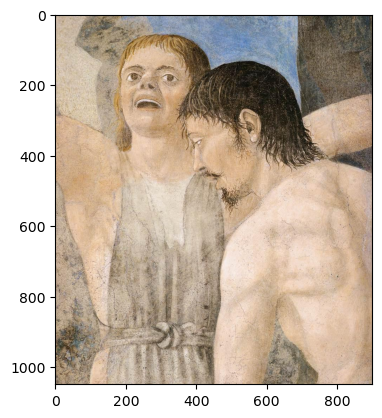

In [170]:
plt.imshow(cv2.cvtColor(cv2.imread('./data/cours_23-03/piero/31421.jpg'), cv2.COLOR_BGR2RGB))

In [163]:
df.sort_values('surface_ratio')

,ID,artist,title,picture data,file info,jpg url,detail,original_title,date,location,city,technique,object_dimensions,year,path,surface_ratio
136,31449,PIERO DELLA FRANCESCA,polyptych of st augustine: augustinian saint,"c. 1460, tempera on panel, 39 x 28 cm, frick c...","863*1200, true color, 158 kb",https://www.wga.hu/art/p/piero/1/2august7.jpg,False,polyptych of st augustine: augustinian saint,c. 1460,frick collection,new york,tempera on panel,39 x 28 cm,1460.0,./data/piero/31449.jpg,0.003505
124,31437,PIERO DELLA FRANCESCA,polyptych of the misericordia: madonna of mercy,"1460-62, oil and tempera on panel, 134 x 91 cm...","900*1341, true color, 169 kb",https://www.wga.hu/art/p/piero/1/1miser04.jpg,False,polyptych of the misericordia: madonna of mercy,1460-62,pinacoteca comunale,sansepolcro,oil and tempera on panel,134 x 91 cm,1460.0,./data/piero/31437.jpg,0.003835
55,31368,PIERO DELLA FRANCESCA,sigismondo pandolfo malatesta,"1451, oil and tempera on panel, 44 x 34 cm, mu...","802*1065, true color, 137 kb",https://www.wga.hu/art/p/piero/4/malatest.jpg,False,sigismondo pandolfo malatesta,1451,musée du louvre,paris,oil and tempera on panel,44 x 34 cm,1451.0,./data/piero/31368.jpg,0.005269
78,31391,PIERO DELLA FRANCESCA,st jerome and a donor,"1451, panel, 49 x 42 cm, gallerie dell'accadem...","900*1112, true color, 173 kb",https://www.wga.hu/art/p/piero/3/03jerome.jpg,False,st jerome and a donor,1451,gallerie dell'accademia,venice,panel,49 x 42 cm,1451.0,./data/piero/31391.jpg,0.006775
49,31362,PIERO DELLA FRANCESCA,montefeltro altarpiece (detail),"1472-74, oil on panel, pinacoteca di brera, milan","900*1344, true color, 153 kb",https://www.wga.hu/art/p/piero/3/12monte4.jpg,True,montefeltro altarpiece,1472-74,pinacoteca di brera,milan,oil on panel,NaN,1472.0,./data/piero/31362.jpg,0.013724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,31337,PIERO DELLA FRANCESCA,7b. recognition of the true cross (detail),"1452-66, fresco, san francesco, arezzo","1000*1148, true color, 201 kb",https://www.wga.hu/art/p/piero/2/7/7find12.jpg,True,7b. recognition of the true cross,1452-66,san francesco,arezzo,fresco,NaN,1452.0,./data/piero/31337.jpg,0.453745
25,31338,PIERO DELLA FRANCESCA,7b. recognition of the true cross (detail),"1452-66, fresco, san francesco, arezzo","1000*1169, true color, 214 kb",https://www.wga.hu/art/p/piero/2/7/7find13.jpg,True,7b. recognition of the true cross,1452-66,san francesco,arezzo,fresco,NaN,1452.0,./data/piero/31338.jpg,0.464778
110,31423,PIERO DELLA FRANCESCA,1. death of adam (detail),"1452-66, fresco, san francesco, arezzo","900*1051, true color, 171 kb",https://www.wga.hu/art/p/piero/2/1/1adam12.jpg,True,1. death of adam,1452-66,san francesco,arezzo,fresco,NaN,1452.0,./data/piero/31423.jpg,0.468210
108,31421,PIERO DELLA FRANCESCA,1. death of adam (detail),"1452-66, fresco, san francesco, arezzo","900*1049, true color, 185 kb",https://www.wga.hu/art/p/piero/2/1/1adam10.jpg,True,1. death of adam,1452-66,san francesco,arezzo,fresco,NaN,1452.0,./data/piero/31421.jpg,0.532231
